# ⚛️ PINN for an Inverse Problem: Beam Deflection

**Objective:** This notebook extends the previous PINN project to solve an inverse problem. Given a few sparse measurements of a beam's deflection, we will use the PINN to determine the unknown uniform load `q` that caused the deflection.

**Method:** We will treat the unknown load `q` as a learnable parameter. The training is split into two stages: first, pre-training the network to fit the data, and second, fine-tuning the entire system to discover the unknown physical parameter.

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Problem Definition and Synthetic Data Generation

In [2]:
# --- Known Physics and Geometry Parameters ---
E = 210e9  # Young's Modulus for steel (Pa)
I = 3.255e-6 # Moment of inertia for a sample beam (m^4)
L = 5.0    # Length of the beam (m)
EI = E * I

# --- The TRUE (unknown) load we want to find ---
q_true = -15000.0 # The actual uniform load (N/m)

# Analytical solution function (used to generate sensor data)
def analytical_solution(x, q, E, I, L):
    return (q * x / (24 * E * I)) * (L**3 - 2 * L * x**2 + x**3)

# --- Generate Synthetic Sensor Data ---
n_sensors = 7
x_sensor = torch.linspace(0, L, n_sensors + 2)[1:-1].view(-1, 1).to(device) # Exclude supports
u_sensor = analytical_solution(x_sensor.cpu().numpy(), q_true, E, I, L)
u_sensor = torch.from_numpy(u_sensor).float().to(device)

## 3. The Neural Network and Learnable Parameters

In [3]:
class PINN(nn.Module):
    def __init__(self, L, hidden_size=64):
        super(PINN, self).__init__()
        self.L = L
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return x * (self.L - x) * self.net(x)

model = PINN(L).to(device)

q_param = nn.Parameter(torch.tensor([-5000.0], device=device))

## 4. The Modified Loss Function

In [4]:
def physics_informed_loss(model, q_param, x_collocation, x_boundary, x_sensor, u_sensor, EI):
    # Data loss
    u_pred_sensor = model(x_sensor)
    loss_data = torch.mean((u_pred_sensor - u_sensor)**2)

    # Moment boundary condition loss
    u_b = model(x_boundary)
    du_dx_b = torch.autograd.grad(u_b, x_boundary, grad_outputs=torch.ones_like(u_b), create_graph=True)[0]
    d2u_dx2_b = torch.autograd.grad(du_dx_b, x_boundary, grad_outputs=torch.ones_like(du_dx_b), create_graph=True)[0]
    loss_bc = torch.mean((d2u_dx2_b)**2)
    
    # Physics loss
    u = model(x_collocation)
    du_dx = torch.autograd.grad(u, x_collocation, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x_collocation, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    d3u_dx3 = torch.autograd.grad(d2u_dx2, x_collocation, grad_outputs=torch.ones_like(d2u_dx2), create_graph=True)[0]
    d4u_dx4 = torch.autograd.grad(d3u_dx3, x_collocation, grad_outputs=torch.ones_like(d3u_dx3), create_graph=True)[0]
    
    residual = EI * d4u_dx4 - q_param
    loss_physics = torch.mean(residual**2)
    
    return loss_data, loss_bc, loss_physics

## 5. Model Training (Two-Stage Approach)

In [5]:
n_collocation = 800
x_boundary = torch.tensor([0.0, L]).float().view(-1, 1).to(device).requires_grad_(True)

q_history = []
loss_history = {'total': [], 'data': [], 'boundary': [], 'physics': []}

# --- Phase 1: Pre-train the network on data only --- 
print("--- Starting Phase 1: Pre-training Network Shape ---")
pretrain_epochs = 10000
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(pretrain_epochs):
    pretrain_optimizer.zero_grad()
    
    u_pred_sensor = model(x_sensor)
    loss_data_pre = torch.mean((u_pred_sensor - u_sensor)**2)
    
    u_b = model(x_boundary)
    du_dx_b = torch.autograd.grad(u_b, x_boundary, grad_outputs=torch.ones_like(u_b), create_graph=True)[0]
    d2u_dx2_b = torch.autograd.grad(du_dx_b, x_boundary, grad_outputs=torch.ones_like(du_dx_b), create_graph=True)[0]
    loss_bc_pre = torch.mean((d2u_dx2_b)**2)
    
    pretrain_loss = 100 * loss_data_pre + loss_bc_pre
    pretrain_loss.backward()
    pretrain_optimizer.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f'Pre-train Epoch [{epoch+1:5d}/{pretrain_epochs}] | Loss: {pretrain_loss.item():.2e}')

# --- Phase 2: Fine-tune the entire system --- 
print("\n--- Starting Phase 2: Fine-tuning to find q ---")
finetune_epochs = 10000
optimizer = torch.optim.Adam(list(model.parameters()) + [q_param], lr=5e-4)

for epoch in range(finetune_epochs):
    optimizer.zero_grad()
    
    x_collocation = (torch.rand(n_collocation, 1, requires_grad=True) * L).to(device)

    loss_data, loss_bc, loss_physics = physics_informed_loss(
        model, q_param, x_collocation, x_boundary, x_sensor, u_sensor, EI
    )

    total_loss = 100 * loss_data + 1.0 * loss_bc + 1.0 * loss_physics
    
    total_loss.backward()
    optimizer.step()

    q_history.append(q_param.item())
    loss_history['total'].append(total_loss.item())

    if (epoch + 1) % 1000 == 0:
        print(f'Finetune Epoch [{epoch+1:5d}/{finetune_epochs}] | '
              f'Total: {total_loss.item():.2e} | '
              f'q: {q_param.item():.2f}')
        
print("\nTraining completed!")
print(f"True load: {q_true:.2f} N/m")
print(f"Learned load: {q_param.item():.2f} N/m")
final_error_pct = abs(q_param.item() - q_true) / abs(q_true) * 100
print(f"Error: {abs(q_param.item() - q_true):.2f} N/m ({final_error_pct:.2f}%)")

--- Starting Phase 1: Pre-training Network Shape ---
Pre-train Epoch [ 1000/10000] | Loss: 8.59e-04
Pre-train Epoch [ 2000/10000] | Loss: 5.76e-04
Pre-train Epoch [ 3000/10000] | Loss: 3.96e-04
Pre-train Epoch [ 4000/10000] | Loss: 2.37e-04
Pre-train Epoch [ 5000/10000] | Loss: 1.45e-04
Pre-train Epoch [ 6000/10000] | Loss: 1.12e-01
Pre-train Epoch [ 7000/10000] | Loss: 8.12e-05
Pre-train Epoch [ 8000/10000] | Loss: 5.11e-05
Pre-train Epoch [ 9000/10000] | Loss: 3.64e-05
Pre-train Epoch [10000/10000] | Loss: 4.67e-04

--- Starting Phase 2: Fine-tuning to find q ---
Finetune Epoch [ 1000/10000] | Total: 3.05e+04 | q: -5000.00
Finetune Epoch [ 2000/10000] | Total: 2.49e+06 | q: -5000.00
Finetune Epoch [ 3000/10000] | Total: 4.88e+05 | q: -5000.00
Finetune Epoch [ 4000/10000] | Total: 7.73e+06 | q: -5000.00
Finetune Epoch [ 5000/10000] | Total: 3.85e+03 | q: -5000.00
Finetune Epoch [ 6000/10000] | Total: 1.14e+03 | q: -5000.00
Finetune Epoch [ 7000/10000] | Total: 7.30e+04 | q: -5000.00
F

## 6. Results and Visualization

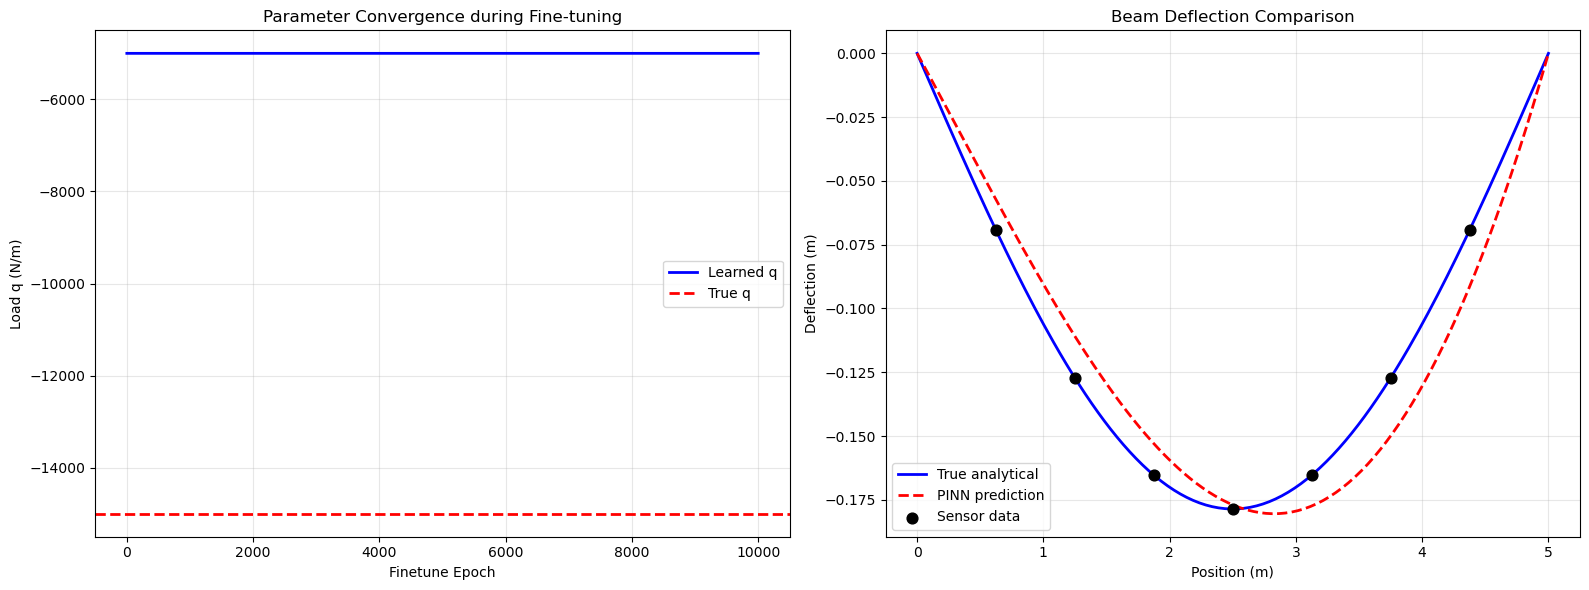

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Parameter convergence
axes[0].plot(q_history, 'b-', linewidth=2, label='Learned q')
axes[0].axhline(y=q_true, color='r', linestyle='--', linewidth=2, label='True q')
axes[0].set_xlabel('Finetune Epoch')
axes[0].set_ylabel('Load q (N/m)')
axes[0].set_title('Parameter Convergence during Fine-tuning')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Solution comparison
model.eval()
x_test = torch.linspace(0, L, 200).view(-1, 1).to(device)
with torch.no_grad():
    u_pred = model(x_test).cpu().numpy().flatten()

x_analytical = np.linspace(0, L, 200)
u_analytical = analytical_solution(x_analytical, q_true, E, I, L)

axes[1].plot(x_analytical, u_analytical, 'b-', linewidth=2, label='True analytical')
axes[1].plot(x_test.cpu().numpy(), u_pred, 'r--', linewidth=2, label='PINN prediction')
axes[1].scatter(x_sensor.cpu().numpy(), u_sensor.cpu().numpy(), 
                 color='black', s=60, zorder=5, label='Sensor data')
axes[1].set_xlabel('Position (m)')
axes[1].set_ylabel('Deflection (m)')
axes[1].set_title('Beam Deflection Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()